In [1]:
# This is for brain
# Install kaggle package in the notebook environment (magic command)
%pip install kaggle

import os
import json
import zipfile
import shutil
import subprocess
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader, random_split
from PIL import Image

# Kaggle API (used instead of shelling out to the kaggle CLI)
from kaggle.api.kaggle_api_extended import KaggleApi

# =============================================================================
# PART 1: KAGGLE AND DATA SETUP
# =============================================================================

def setup_kaggle():
    """Sets up Kaggle credentials."""
    kaggle_dir = os.path.expanduser("~/.kaggle")
    os.makedirs(kaggle_dir, exist_ok=True)
    kaggle_json_path = 'kaggle.json'
    if os.path.exists(kaggle_json_path):
        with open(kaggle_json_path, 'r') as f:
            kaggle_credentials = json.load(f)
        # Ensure the credentials are available under ~/.kaggle/kaggle.json (required by KaggleApi)
        dest_path = os.path.join(kaggle_dir, 'kaggle.json')
        with open(dest_path, 'w') as f:
            json.dump(kaggle_credentials, f)
        try:
            os.chmod(dest_path, 0o600)
        except Exception:
            # Not critical on some platforms (e.g., Windows), so ignore chmod failures
            pass
        print("✅ Loaded Kaggle credentials from kaggle.json and wrote to ~/.kaggle/kaggle.json")
    else:
        # Try to create kaggle.json from environment variables if present
        kaggle_username = os.environ.get('KAGGLE_USERNAME')
        kaggle_key = os.environ.get('KAGGLE_KEY') or os.environ.get('KAGGLE_API_KEY')
        if kaggle_username and kaggle_key:
            kaggle_credentials = {"username": kaggle_username, "key": kaggle_key}
            dest_path = os.path.join(kaggle_dir, 'kaggle.json')
            with open(dest_path, 'w') as f:
                json.dump(kaggle_credentials, f)
            try:
                os.chmod(dest_path, 0o600)
            except Exception:
                pass
            print("✅ Created ~/.kaggle/kaggle.json from KAGGLE_USERNAME and KAGGLE_KEY environment variables")
        else:
            raise FileNotFoundError(
                "kaggle.json not found and KAGGLE_USERNAME/KAGGLE_KEY not set. "
                "Place a valid kaggle.json in the notebook working directory or set environment variables."
            )

def download_and_extract(dataset_name, zip_file_name, extract_dir, max_attempts=1):
    """Downloads and extracts the Brain MRI Kaggle dataset.

    This version uses the Kaggle Python API (KaggleApi). It requires that
    ~/.kaggle/kaggle.json exists (the setup_kaggle function creates it).
    """
    if not os.path.exists(zip_file_name):
        print(f"⬇️ Attempting to download {dataset_name} dataset using KaggleApi...")

        try:
            api = KaggleApi()
            api.authenticate()
            # Download dataset files as a zip into current directory
            api.dataset_download_files(dataset_name, path='.', unzip=False)
        except Exception as e:
            # Provide helpful error message including the original exception
            raise RuntimeError(
                "Failed to download dataset via KaggleApi. Ensure the 'kaggle' package is installed, "
                "and ~/.kaggle/kaggle.json contains valid credentials. Original error: " + str(e)
            )

    # After attempting download, ensure the expected zip exists
    if not os.path.exists(zip_file_name):
        raise FileNotFoundError(
            f"Expected zip file '{zip_file_name}' not found after download attempt. "
            "Check KaggleApi output and that the dataset name is correct."
        )

    if not os.path.exists(extract_dir):
        print(f"📦 Extracting {zip_file_name}...")
        with zipfile.ZipFile(zip_file_name, "r") as zip_ref:
            zip_ref.extractall(extract_dir)
    print(f"✅ {dataset_name} dataset ready.")
    if not os.path.exists(extract_dir):
        print(f"📦 Extracting {zip_file_name}...")
        with zipfile.ZipFile(zip_file_name, "r") as zip_ref:
            zip_ref.extractall(extract_dir)
    print(f"✅ {dataset_name} dataset ready.")
    print(f"✅ {dataset_name} dataset ready.")

def prepare_brain_mri_data(extract_dir="brain_mri_extracted"):
    """Cleans and prepares the Brain MRI dataset."""
    print("\n🧠 Preparing Brain MRI dataset...")
    messy_root_dir = os.path.join(extract_dir, 'brain_tumor_dataset')
    cleaned_dir = os.path.join(extract_dir, "cleaned_dataset")
    if os.path.exists(cleaned_dir): shutil.rmtree(cleaned_dir)
    os.makedirs(os.path.join(cleaned_dir, "yes"), exist_ok=True)
    os.makedirs(os.path.join(cleaned_dir, "no"), exist_ok=True)

    def copy_files(src, dest):
        if not os.path.exists(src): return
        for filename in os.listdir(src):
            if os.path.isfile(os.path.join(src, filename)):
                shutil.copy(os.path.join(src, filename), dest)
    copy_files(os.path.join(messy_root_dir, 'yes'), os.path.join(cleaned_dir, "yes"))
    copy_files(os.path.join(messy_root_dir, 'no'), os.path.join(cleaned_dir, "no"))

    full_dataset = datasets.ImageFolder(root=cleaned_dir)
    return full_dataset

# =============================================================================
# PART 2: MODEL TRAINING
# =============================================================================

def train_brain_model(train_dataset, val_dataset, num_classes, num_epochs=15):
    """Trains the ResNet-50 model for Brain MRI classification."""
    num_workers = 0 if os.name == 'nt' else 2
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=num_workers)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\n💻 Using device: {device}")

    model = models.resnet50(weights='IMAGENET1K_V1')
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=2, factor=0.1)
    best_acc = 0.0

    print("\n🚀 Starting Brain MRI model training...")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_acc = 100 * correct / total
        scheduler.step(val_acc)
        print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {epoch_loss:.4f}, Val Acc: {val_acc:.2f}%")

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_brain_model.pth")
            print(f"  ✨ New best model saved with accuracy: {best_acc:.2f}%")

    print("\n✅ Training complete! Model saved as: best_brain_model.pth")

# =============================================================================
# PART 3: MAIN EXECUTION BLOCK
# =============================================================================
if __name__ == "__main__":
    setup_kaggle()

    download_and_extract(
        "navoneel/brain-mri-images-for-brain-tumor-detection",
        "brain-mri-images-for-brain-tumor-detection.zip",
        "brain_mri_extracted"
    )

    full_dataset = prepare_brain_mri_data()
    class_names = full_dataset.classes

    with open('brain_class_names.json', 'w') as f:
        json.dump(class_names, f)
    print(f"✅ Class names saved to brain_class_names.json: {class_names}")

    data_transforms = {
        'train': transforms.Compose([
            transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.1, contrast=0.1), transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
        'val': transforms.Compose([
            transforms.Resize(256), transforms.CenterCrop(224), transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ]),
    }

    train_size = int(0.8 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_subset, val_subset = random_split(full_dataset, [train_size, val_size])
    train_subset.dataset.transform = data_transforms['train']
    val_subset.dataset.transform = data_transforms['val']

    train_brain_model(train_subset, val_subset, len(class_names), num_epochs=15)



Note: you may need to restart the kernel to use updated packages.
✅ Loaded Kaggle credentials from kaggle.json and wrote to ~/.kaggle/kaggle.json
✅ navoneel/brain-mri-images-for-brain-tumor-detection dataset ready.
✅ navoneel/brain-mri-images-for-brain-tumor-detection dataset ready.
✅ navoneel/brain-mri-images-for-brain-tumor-detection dataset ready.

🧠 Preparing Brain MRI dataset...
✅ Class names saved to brain_class_names.json: ['no', 'yes']

💻 Using device: cpu

🚀 Starting Brain MRI model training...
Epoch 1/15 -> Train Loss: 0.4862, Val Acc: 82.35%
  ✨ New best model saved with accuracy: 82.35%
Epoch 2/15 -> Train Loss: 0.1002, Val Acc: 84.31%
  ✨ New best model saved with accuracy: 84.31%
Epoch 3/15 -> Train Loss: 0.0179, Val Acc: 84.31%
Epoch 4/15 -> Train Loss: 0.0066, Val Acc: 82.35%
Epoch 5/15 -> Train Loss: 0.0057, Val Acc: 84.31%
Epoch 6/15 -> Train Loss: 0.0143, Val Acc: 84.31%
Epoch 7/15 -> Train Loss: 0.0026, Val Acc: 84.31%
Epoch 8/15 -> Train Loss: 0.0023, Val Acc: 84.3

In [ ]:
# This is for xray
import os
import json
import zipfile
import shutil
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image

# =============================================================================
# PART 1: KAGGLE AND DATA SETUP
# =============================================================================

def setup_kaggle():
    """Sets up Kaggle credentials."""
    kaggle_dir = os.path.expanduser("~/.kaggle")
    os.makedirs(kaggle_dir, exist_ok=True)
    kaggle_json_path = 'kaggle.json'
    if os.path.exists(kaggle_json_path):
        with open(kaggle_json_path, 'r') as f:
            kaggle_credentials = json.load(f)
        print("✅ Loaded Kaggle credentials from kaggle.json")
    else:
        print("⚠️ kaggle.json not found. Using placeholder credentials.")
        kaggle_credentials = {"username": "your_kaggle_username", "key": "your_kaggle_api_key"}
    with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
        json.dump(kaggle_credentials, f)
    os.chmod(os.path.join(kaggle_dir, 'kaggle.json'), 0o600)
    print("✅ Kaggle credentials set up!")

def download_and_extract(dataset_name, zip_file_name, extract_dir):
    """Downloads and extracts the NIH X-ray Kaggle dataset."""
    if not os.path.exists(zip_file_name):
        print(f"⬇️ Downloading {dataset_name} dataset...")
        os.system(f"kaggle datasets download -d {dataset_name}")
    if not os.path.exists(extract_dir):
        print(f"📦 Extracting {zip_file_name}...")
        with zipfile.ZipFile(zip_file_name, "r") as zip_ref:
            zip_ref.extractall(extract_dir)
    print(f"✅ {dataset_name} dataset ready.")

# =============================================================================
# PART 2: DATASET-SPECIFIC PREPARATION
# =============================================================================

class ChestXRayDataset(Dataset):
    """Custom PyTorch Dataset for the NIH Chest X-ray data."""
    def __init__(self, csv_file, img_dir, transform=None):
        self.data_frame = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.transform = transform
        # Create a sorted list of unique labels, excluding "No Finding"
        all_labels_raw = set([label for sublist in self.data_frame['Finding Labels'].str.split('|') for label in sublist])
        if 'No Finding' in all_labels_raw:
            all_labels_raw.remove('No Finding')
        self.all_labels = sorted(list(all_labels_raw))

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, self.data_frame.loc[idx, 'Image Index'])
        image = Image.open(img_name).convert('RGB')

        # Create a multi-hot encoded target tensor
        labels_str = self.data_frame.loc[idx, 'Finding Labels']
        labels = labels_str.split('|')
        target = torch.zeros(len(self.all_labels), dtype=torch.float32)
        for label in labels:
            if label in self.all_labels:
                target[self.all_labels.index(label)] = 1

        if self.transform:
            image = self.transform(image)

        return image, target

def find_xray_paths(extract_dir):
    """Robustly finds the CSV and images directory by cross-referencing."""
    csv_path = None
    for root, _, files in os.walk(extract_dir):
        if "Data_Entry_2017.csv" in files:
            csv_path = os.path.join(root, "Data_Entry_2017.csv")
            break
    if csv_path is None: raise FileNotFoundError("Could not find 'Data_Entry_2017.csv'")

    df = pd.read_csv(csv_path)
    if df.empty: raise ValueError("CSV file 'Data_Entry_2017.csv' is empty.")

    sample_image_filename = df['Image Index'].iloc[0]
    image_dir_path = None
    for root, _, files in os.walk(extract_dir):
        if sample_image_filename in files:
            image_dir_path = root
            break
    if image_dir_path is None: raise FileNotFoundError(f"Could not find sample image '{sample_image_filename}'")

    return csv_path, image_dir_path

def prepare_xray_data(extract_dir="nih_xray_extracted"):
    """Prepares the NIH Chest X-ray dataset."""
    print("\n🩻 Preparing NIH Chest X-ray dataset...")
    csv_path, image_dir_path = find_xray_paths(extract_dir)
    print(f"  - Found CSV at: {csv_path}")
    print(f"  - Found images directory at: {image_dir_path}")
    full_dataset = ChestXRayDataset(csv_file=csv_path, img_dir=image_dir_path)
    return full_dataset

# =============================================================================
# PART 3: MODEL TRAINING
# =============================================================================

def train_xray_model(train_dataset, val_dataset, num_classes, num_epochs=15):
    """Trains the ResNet-50 model for X-ray multi-label classification."""
    num_workers = 0 if os.name == 'nt' else 2
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=num_workers)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=num_workers)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"\n💻 Using device: {device}")

    model = models.resnet50(weights='IMAGENET1K_V1')
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    model = model.to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.1)
    best_loss = float('inf')

    print("\n🚀 Starting Chest X-ray model training...")

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)

        avg_val_loss = val_loss / len(val_loader.dataset)
        scheduler.step(avg_val_loss)
        print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {epoch_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(), "best_xray_model.pth")
            print(f"  ✨ New best model saved with validation loss: {best_loss:.4f}")

    print("\n✅ Training complete! Model saved as: best_xray_model.pth")

# =============================================================================
# PART 4: MAIN EXECUTION BLOCK
# =============================================================================
if __name__ == "__main__":
    setup_kaggle()

    download_and_extract(
        "khanfashee/nih-chest-x-ray-14-224x224-resized",
        "nih-chest-x-ray-14-224x224-resized.zip",
        "nih_xray_extracted"
    )

    full_dataset = prepare_xray_data(extract_dir="nih_xray_extracted")
    class_names = full_dataset.all_labels

    with open('xray_class_names.json', 'w') as f:
        json.dump(class_names, f)
    print(f"✅ Class names saved to xray_class_names.json: {class_names}")

    # Using a smaller subset for faster training demonstration
    subset_size = 5000
    subset_indices = np.random.choice(range(len(full_dataset)), subset_size, replace=False)
    subset = torch.utils.data.Subset(full_dataset, subset_indices)

    train_size = int(0.8 * len(subset))
    val_size = len(subset) - train_size
    train_subset, val_subset = random_split(subset, [train_size, val_size])

    # Apply transforms to the underlying dataset for the subsets
    train_subset.dataset.dataset.transform = transforms.Compose([
        transforms.Resize(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    val_subset.dataset.dataset.transform = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    train_xray_model(train_subset, val_subset, len(class_names), num_epochs=15)


✅ Loaded Kaggle credentials from kaggle.json
✅ Kaggle credentials set up!
✅ khanfashee/nih-chest-x-ray-14-224x224-resized dataset ready.

🩻 Preparing NIH Chest X-ray dataset...
  - Found CSV at: nih_xray_extracted\Data_Entry_2017.csv
  - Found images directory at: nih_xray_extracted\images-224\images-224
✅ Class names saved to xray_class_names.json: ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion', 'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule', 'Pleural_Thickening', 'Pneumonia', 'Pneumothorax']

💻 Using device: cpu

🚀 Starting Chest X-ray model training...


Epoch 1/15 -> Train Loss: 0.2087, Val Loss: 0.1620
  ✨ New best model saved with validation loss: 0.1620
Epoch 2/15 -> Train Loss: 0.1503, Val Loss: 0.1659
Epoch 3/15 -> Train Loss: 0.1252, Val Loss: 0.1706
Epoch 4/15 -> Train Loss: 0.0860, Val Loss: 0.2091
Epoch 5/15 -> Train Loss: 0.0490, Val Loss: 0.1829
Epoch 6/15 -> Train Loss: 0.0336, Val Loss: 0.1873
Epoch 7/15 -> Train Loss: 0.0266, Val Loss: 0.1927
Epoch 8/15 -> Train Loss: 0.0225, Val Loss: 0.1899
Epoch 9/15 -> Train Loss: 0.0219, Val Loss: 0.1914
Epoch 10/15 -> Train Loss: 0.0215, Val Loss: 0.1912


Attempting to predict using the 'xray' model...
Analyzing image: 'chest.webp'


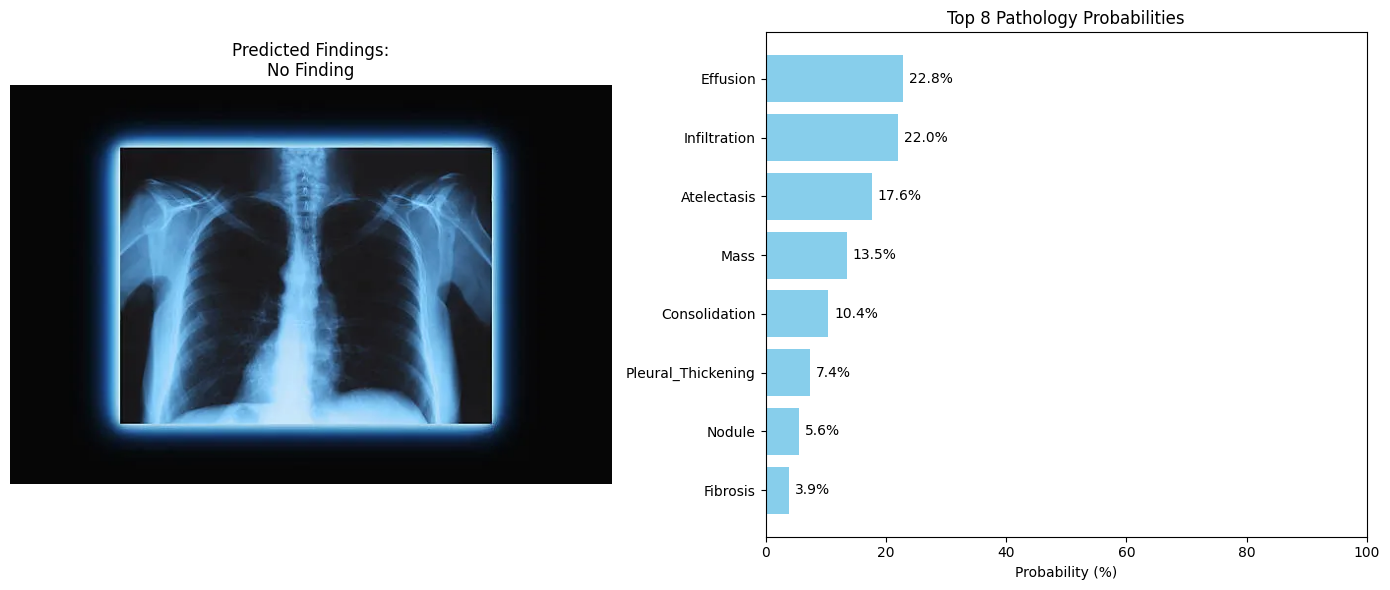

In [1]:
import os
import json
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# PART 1: PREDICTION AND VISUALIZATION FUNCTIONS FOR EACH TASK
# =============================================================================

# --- BRAIN PREDICTION FUNCTIONS (ResNet-50) ---
def load_brain_model(model_path, num_classes):
    """Loads the saved ResNet-50 model for brain tumor prediction."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = models.resnet50(weights=None)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    model.load_state_dict(torch.load(model_path, map_location=device))

    model = model.to(device)
    model.eval()
    return model, device


def predict_brain_image(model, image_path, device, class_names):
    """Runs prediction on a single brain MRI image."""
    transform = transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)

    predicted_label = class_names[predicted_idx.item()]
    confidence_score = confidence.item() * 100
    probs_list = probabilities.cpu().numpy().flatten()
    probabilities_dict = {class_names[i]: probs_list[i] * 100
                          for i in range(len(class_names))}

    return {
        'prediction': predicted_label,
        'confidence': confidence_score,
        'probabilities': probabilities_dict,
        'image': image
    }


def visualize_brain_prediction(result):
    """Displays the brain MRI prediction results."""
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(result['image'])
    title_color = 'red' if result['prediction'] == 'yes' else 'green'
    plt.title(f"Prediction: {result['prediction']}\nConfidence: {result['confidence']:.2f}%",
              color=title_color)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    classes = list(result['probabilities'].keys())
    probs = list(result['probabilities'].values())
    bar_colors = ['red' if c == 'yes' else 'green' for c in classes]
    plt.barh(classes, probs, color=bar_colors, alpha=0.8)
    plt.xlabel('Probability (%)')
    plt.title('Class Probabilities')
    plt.xlim(0, 100)
    for i, prob in enumerate(probs):
        plt.text(prob + 1, i, f'{prob:.1f}%', va='center')

    plt.tight_layout()
    plt.show()



# --- X-RAY PREDICTION FUNCTIONS (FIXED → DenseNet-121) ---
def load_xray_model(model_path, num_classes):
    """Loads the saved DenseNet-121 model for X-ray pathology prediction."""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # 🔥 FIX: Use DenseNet since checkpoint contains denseblock layers
    model = models.densenet121(weights=None)

    num_features = model.classifier.in_features
    model.classifier = nn.Linear(num_features, num_classes)

    # Load trained weights
    model.load_state_dict(torch.load(model_path, map_location=device))

    model = model.to(device)
    model.eval()
    return model, device


def predict_xray_image(model, image_path, device, class_names, threshold=0.5):
    """Runs prediction on a single chest X-ray image."""
    transform = transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.sigmoid(outputs)

    probs_list = probabilities.cpu().numpy().flatten()

    predictions = [class_names[i] for i, prob in enumerate(probs_list)
                   if prob > threshold]
    if not predictions:
        predictions = ["No Finding"]

    probabilities_dict = {class_names[i]: probs_list[i] * 100
                          for i in range(len(class_names))}

    return {
        'predictions': predictions,
        'probabilities': probabilities_dict,
        'image': image
    }


def visualize_xray_prediction(result):
    """Displays the chest X-ray prediction results."""
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(result['image'], cmap='gray')
    predicted_text = "\n".join(result['predictions'])
    plt.title(f"Predicted Findings:\n{predicted_text}", fontsize=12)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    sorted_probs = sorted(result['probabilities'].items(),
                          key=lambda item: item[1],
                          reverse=True)[:8]

    classes = [item[0] for item in sorted_probs]
    probs = [item[1] for item in sorted_probs]

    plt.barh(classes, probs, color='skyblue')
    plt.xlabel('Probability (%)')
    plt.title('Top 8 Pathology Probabilities')
    plt.xlim(0, 100)
    plt.gca().invert_yaxis()
    for i, prob in enumerate(probs):
        plt.text(prob + 1, i, f'{prob:.1f}%', va='center')

    plt.tight_layout()
    plt.show()



# =============================================================================
# PART 2: MAIN EXECUTION BLOCK
# =============================================================================

if __name__ == "__main__":

    MODEL_TYPE_TO_USE = 'xray'  # 'brain' or 'xray'

    IMAGE_TO_ANALYZE = "chest.webp"
    # IMAGE_TO_ANALYZE = "test_brain_mri.webp"

    print(f"Attempting to predict using the '{MODEL_TYPE_TO_USE}' model...")
    print(f"Analyzing image: '{IMAGE_TO_ANALYZE}'")

    if not os.path.exists(IMAGE_TO_ANALYZE):
        print(f"❌ Error: Image file not found at '{IMAGE_TO_ANALYZE}'.")
        exit()

    if MODEL_TYPE_TO_USE == 'brain':
        model_path = 'best_brain_model.pth'
        class_names_path = 'brain_class_names.json'

        if not os.path.exists(model_path) or not os.path.exists(class_names_path):
            print("❌ Error: Brain model files not found.")
        else:
            with open(class_names_path, 'r') as f:
                class_names = json.load(f)

            model, device = load_brain_model(model_path, len(class_names))
            result = predict_brain_image(model, IMAGE_TO_ANALYZE, device, class_names)
            visualize_brain_prediction(result)

    elif MODEL_TYPE_TO_USE == 'xray':
        model_path = 'best_xray_model.pth'
        class_names_path = 'xray_class_names.json'

        if not os.path.exists(model_path) or not os.path.exists(class_names_path):
            print("❌ Error: X-ray model files not found.")
        else:
            with open(class_names_path, 'r') as f:
                class_names = json.load(f)

            model, device = load_xray_model(model_path, len(class_names))
            result = predict_xray_image(model, IMAGE_TO_ANALYZE, device, class_names)
            visualize_xray_prediction(result)

    else:
        print(f"❌ Error: Invalid model type '{MODEL_TYPE_TO_USE}'.")
